In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [5]:
print("\nStatistical Summary:\n")
print(df.describe())


Statistical Summary:

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [6]:
df = df[['survived', 'pclass', 'sex', 'age', 'fare']]

print("\nSelected Features:\n")
print(df.head())


Selected Features:

   survived  pclass     sex   age     fare
0         0       3    male  22.0   7.2500
1         1       1  female  38.0  71.2833
2         1       3  female  26.0   7.9250
3         1       1  female  35.0  53.1000
4         0       3    male  35.0   8.0500


In [7]:
print("\nMissing Values Before:\n")
print(df.isnull().sum())


Missing Values Before:

survived      0
pclass        0
sex           0
age         177
fare          0
dtype: int64


In [8]:
df['age'] = df['age'].fillna(df['age'].mean())

In [9]:
print("\nMissing Values After:\n")
print(df.isnull().sum())


Missing Values After:

survived    0
pclass      0
sex         0
age         0
fare        0
dtype: int64


In [10]:
df['sex'] = df['sex'].map({
    'male': 0,
    'female': 1
})

print("\nEncoded Dataset:\n")
print(df.head())


Encoded Dataset:

   survived  pclass  sex   age     fare
0         0       3    0  22.0   7.2500
1         1       1    1  38.0  71.2833
2         1       3    1  26.0   7.9250
3         1       1    1  35.0  53.1000
4         0       3    0  35.0   8.0500


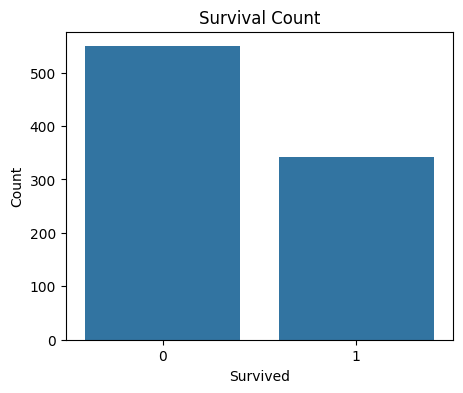

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(x='survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

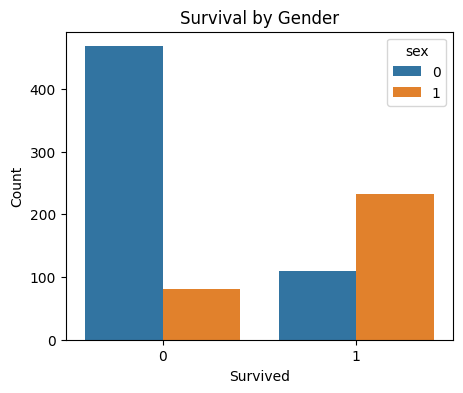

In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(x='survived', hue='sex', data=df)

plt.title("Survival by Gender")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

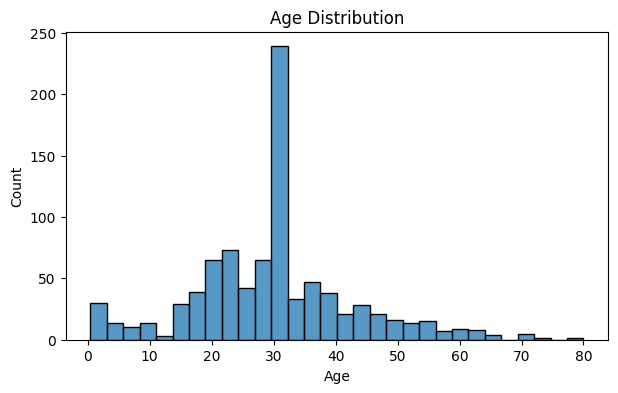

In [13]:
plt.figure(figsize=(7, 4))
sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

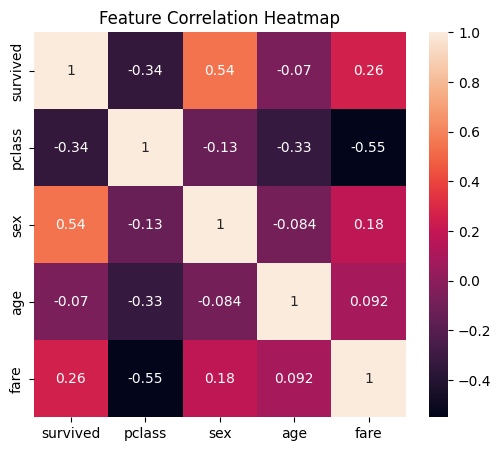

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [15]:
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (712, 4)
Testing Data Shape: (179, 4)


In [17]:
model = GaussianNB()

In [18]:
model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


In [19]:
y_pred = model.predict(X_test)

print("\nPredictions:\n")
print(y_pred[:10])


Predictions:

[0 0 0 1 1 1 1 0 1 1]


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)


Model Accuracy:
0.7597765363128491


In [21]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[83 22]
 [21 53]]


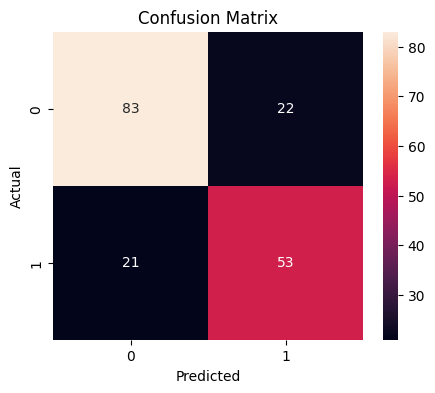

In [22]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
report = classification_report(y_test, y_pred)

print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       105
           1       0.71      0.72      0.71        74

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



In [25]:
sample_passenger = pd.DataFrame({
    'pclass': [1],
    'sex': [1],
    'age': [22],
    'fare': [80]
})

prediction = model.predict(sample_passenger)

probability = model.predict_proba(sample_passenger)

print("\nCustom Passenger Prediction:")

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

print("\nPrediction Probability:")
print(probability)


Custom Passenger Prediction:
Passenger Survived

Prediction Probability:
[[0.01853893 0.98146107]]
